In [1]:
# Celda 1 — Instalar dependencias y montar Drive
!pip install wandb lightgbm -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score
from lightgbm import LGBMClassifier
from google.colab import drive
import pickle
import warnings
import wandb
from google.colab import userdata

wandb.login(key=userdata.get('WANDB_API_KEY'))

warnings.filterwarnings("ignore", category=FutureWarning)

np.random.seed(42)

drive.mount("/content/drive")
DRIVE_PATH = "/content/drive/MyDrive/ProyectoHIGGS/"

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")
print("Setup completado.")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: diego-munozc (diego-munozc-universidad-de-antioquia) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Mounted at /content/drive
Setup completado.


In [2]:
# Celda 2 — Cargar splits desde Drive
X_train = np.load(DRIVE_PATH + "X_train.npy")
X_val   = np.load(DRIVE_PATH + "X_val.npy")
X_test  = np.load(DRIVE_PATH + "X_test.npy")
y_train = np.load(DRIVE_PATH + "y_train.npy")
y_val   = np.load(DRIVE_PATH + "y_val.npy")
y_test  = np.load(DRIVE_PATH + "y_test.npy")

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# Separar 10% de train como eval set para early stopping
X_tr, X_ev, y_tr, y_ev = train_test_split(
    X_train, y_train, test_size=0.1, stratify=y_train, random_state=42
)
print(f"Train (90%): {X_tr.shape}, Eval (10%): {X_ev.shape}")

Train: (350000, 28), Val: (75000, 28), Test: (75000, 28)
Train (90%): (315000, 28), Eval (10%): (35000, 28)


In [3]:
# Celda 3 — Función de evaluación para LightGBM (5-Fold CV, scaler por fold)
def evaluar_modelo_cv_lgbm(model, X_train, y_train, X_val, y_val, X_test, y_test,
                            nombre, k=5):
    """
    Evalúa LightGBM con K-Fold CV. Scaler dentro de cada fold (sin leakage).
    Cada fold separa 10% del train fold como eval_set para early stopping.
    """
    kf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    auc_folds, f1_folds, acc_folds, prec_folds, rec_folds = [], [], [], [], []

    for tr_idx, vl_idx in kf.split(X_train, y_train):
        scaler_cv = StandardScaler()
        X_tr_fold = scaler_cv.fit_transform(X_train[tr_idx])
        X_vl_fold = scaler_cv.transform(X_train[vl_idx])

        X_sub_tr, X_sub_ev, y_sub_tr, y_sub_ev = train_test_split(
            X_tr_fold, y_train[tr_idx], test_size=0.1,
            stratify=y_train[tr_idx], random_state=42
        )
        model.fit(X_sub_tr, y_sub_tr, eval_set=[(X_sub_ev, y_sub_ev)])
        y_prob = model.predict_proba(X_vl_fold)[:, 1]
        y_pred = model.predict(X_vl_fold)
        auc_folds.append(roc_auc_score(y_train[vl_idx], y_prob))
        f1_folds.append(f1_score(y_train[vl_idx], y_pred))
        acc_folds.append(accuracy_score(y_train[vl_idx], y_pred))
        prec_folds.append(precision_score(y_train[vl_idx], y_pred))
        rec_folds.append(recall_score(y_train[vl_idx], y_pred))

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_val_sc   = scaler.transform(X_val)
    X_test_sc  = scaler.transform(X_test)

    X_sub_tr, X_sub_ev, y_sub_tr, y_sub_ev = train_test_split(
        X_train_sc, y_train, test_size=0.1, stratify=y_train, random_state=42
    )
    model.fit(X_sub_tr, y_sub_tr, eval_set=[(X_sub_ev, y_sub_ev)])

    return {
        "Modelo": nombre,
        "AUC_CV_mean": np.mean(auc_folds),
        "AUC_CV_std":  np.std(auc_folds),
        "F1_CV_mean":  np.mean(f1_folds),
        "F1_CV_std":   np.std(f1_folds),
        "Acc_CV_mean": np.mean(acc_folds),
        "Acc_CV_std":  np.std(acc_folds),
        "Precision_CV_mean": np.mean(prec_folds), "Precision_CV_std": np.std(prec_folds),
        "Recall_CV_mean": np.mean(rec_folds), "Recall_CV_std": np.std(rec_folds),
        "AUC_val": roc_auc_score(y_val,  model.predict_proba(X_val_sc)[:, 1]),
        "F1_val":  f1_score(y_val,  model.predict(X_val_sc)),
        "Acc_val": accuracy_score(y_val, model.predict(X_val_sc)),
        "Precision_val": precision_score(y_val, model.predict(X_val_sc)),
        "Recall_val": recall_score(y_val, model.predict(X_val_sc)),
        "AUC_test": roc_auc_score(y_test, model.predict_proba(X_test_sc)[:, 1]),
        "F1_test":  f1_score(y_test,  model.predict(X_test_sc)),
        "Acc_test": accuracy_score(y_test, model.predict(X_test_sc)),
        "Precision_test": precision_score(y_test, model.predict(X_test_sc)),
        "Recall_test": recall_score(y_test, model.predict(X_test_sc)),
        "_scaler": scaler,
        "_model": model,
    }


def tabla_resultados(resultados_lista):
    """Formatea lista de resultados como DataFrame con IC."""
    rows = []
    for r in resultados_lista:
        rows.append({
            "Modelo": r["Modelo"],
            "AUC CV (mean±2σ)": f"{r['AUC_CV_mean']:.3f} ± {2*r['AUC_CV_std']:.3f}",
            "AUC Val":  f"{r['AUC_val']:.3f}",
            "AUC Test": f"{r['AUC_test']:.3f}",
            "F1 Test":  f"{r['F1_test']:.3f}",
            "Acc Test": f"{r['Acc_test']:.3f}",
            "Precision Test": f"{r['Precision_test']:.3f}",
            "Recall Test": f"{r['Recall_test']:.3f}",
        })
    return pd.DataFrame(rows).set_index("Modelo")

Entrenando LightGBM...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  lr=0.05, leaves=31  , ss=0.7: AUC val = 0.8193  (stop @ iter 500)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  lr=0.05, leaves=31  , ss=1.0: AUC val = 0.8193  (stop @ iter 500)


...

  lr=0.20, leaves=127 , ss=1.0: AUC val = 0.8206  (stop @ iter 53)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  lr=0.20, leaves=255 , ss=0.7: AUC val = 0.8210  (stop @ iter 48)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  lr=0.20, leaves=255 , ss=1.0: AUC val = 0.8210  (stop @ iter 48)


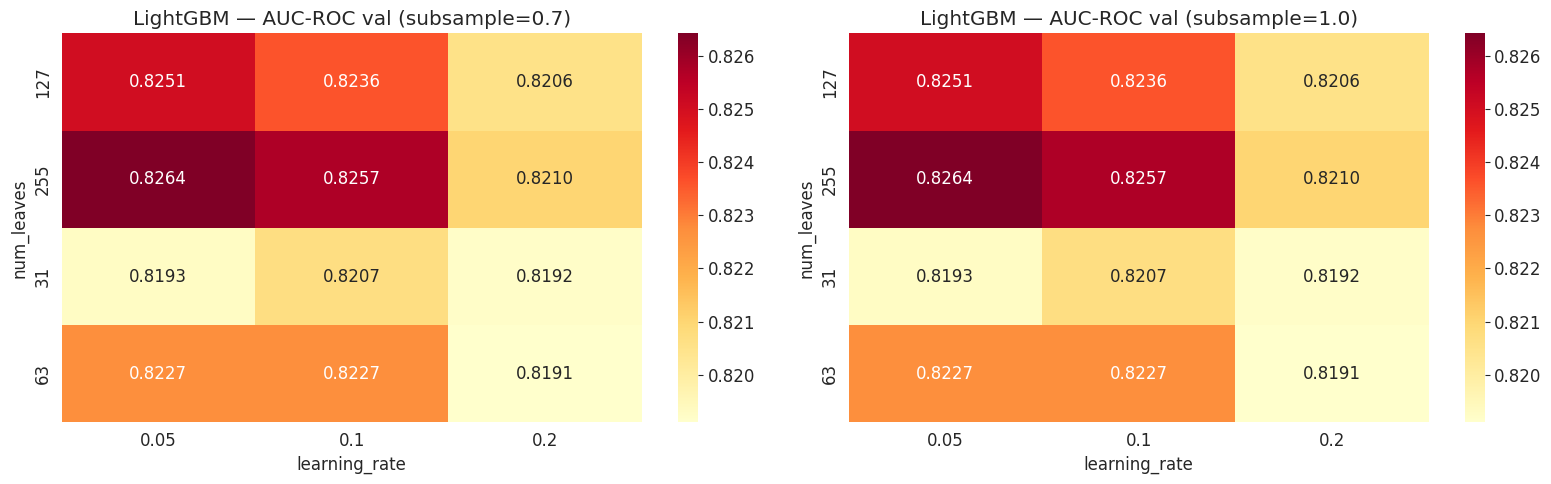


Top 5 configuraciones:
 learning_rate num_leaves  subsample      AUC  n_iter
          0.05        255        0.7 0.826432     224
          0.05        255        1.0 0.826432     224
          0.10        255        1.0 0.825721     145
          0.10        255        0.7 0.825721     145
          0.05        127        0.7 0.825051     387

Mejores parámetros LightGBM: {'learning_rate': 0.05, 'num_leaves': 255, 'subsample': 0.7}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

AUC_CV_2std,▁
AUC_CV_mean,▁
AUC_test,▁
AUC_val,▁▁▄▄▇▇██▃▃▄▄▅▅▇▇▁▁▁▁▂▂▃▃▇
Acc_test,▁
F1_test,▁
lr,▁▁▁▁▁▁▁▁▃▃▃▃▃▃▃▃████████
n_iter,████▆▆▄▄▇▇▅▅▃▃▃▃▄▄▂▂▁▁▁▁
subsample,▁█▁█▁█▁█▁█▁█▁█▁█▁█▁█▁█▁█
AUC_CV_2std,0.00356
AUC_CV_mean,0.82195


In [4]:
# Celda 4 — LightGBM (gradient boosting leaf-wise)
# NOTA: LightGBM crece árboles por hoja (leaf-wise), no por nivel.
# num_leaves controla complejidad (análogo a max_leaf_nodes en HistGB).
# Ke et al. (2017): LightGBM ~0.881 AUC en HIGGS.

nombre_modelo = "LightGBM"

wandb.init(project="higgs-boson", name="LightGBM", config={
    "learning_rate_grid": [0.05, 0.1, 0.2],
    "num_leaves_grid": [31, 63, 127, 255],
    "subsample_grid": [0.7, 1.0],
    "n_estimators": 500,
    "early_stopping_rounds": 20,
})
print(f"Entrenando {nombre_modelo}...")

param_grid_lgbm = {
    "learning_rate": [0.05, 0.1, 0.2],
    "num_leaves":    [31, 63, 127, 255],
    "subsample":     [0.7, 1.0],
}
best_auc_lgbm = 0
best_params_lgbm = {}
lgbm_results_grid = []

for lr in param_grid_lgbm["learning_rate"]:
    for leaves in param_grid_lgbm["num_leaves"]:
        for ss in param_grid_lgbm["subsample"]:
            lgbm = LGBMClassifier(
                n_estimators=500, learning_rate=lr, num_leaves=leaves,
                subsample=ss, feature_fraction=0.8,
                early_stopping_rounds=20, metric="auc",
                random_state=42, n_jobs=-1, verbose=-1
            )
            lgbm.fit(X_tr, y_tr, eval_set=[(X_ev, y_ev)])
            auc = roc_auc_score(y_val, lgbm.predict_proba(X_val)[:, 1])
            n_iter = getattr(lgbm, "best_iteration_", None)
            lgbm_results_grid.append({
                "learning_rate": lr, "num_leaves": str(leaves),
                "subsample": ss, "AUC": auc, "n_iter": n_iter
            })
            wandb.log({"lr": lr, "num_leaves": str(leaves), "subsample": ss,
                        "AUC_val": auc, "n_iter": n_iter})
            print(f"  lr={lr:.2f}, leaves={str(leaves):4s}, ss={ss:.1f}: AUC val = {auc:.4f}  (stop @ iter {n_iter})")
            if auc > best_auc_lgbm:
                best_auc_lgbm = auc
                best_params_lgbm = {"learning_rate": lr, "num_leaves": leaves,
                                     "subsample": ss}

df_lgbm_grid = pd.DataFrame(lgbm_results_grid)

# Dos heatmaps: uno por cada valor de subsample
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
for ax, ss_val in zip(axes, [0.7, 1.0]):
    subset = df_lgbm_grid[df_lgbm_grid["subsample"] == ss_val]
    pivot = subset.pivot(index="num_leaves", columns="learning_rate", values="AUC")
    sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlOrRd", ax=ax)
    ax.set_title(f"LightGBM — AUC-ROC val (subsample={ss_val})")
    ax.set_xlabel("learning_rate")
    ax.set_ylabel("num_leaves")
plt.tight_layout()
plt.savefig(DRIVE_PATH + "fig_lightgbm_hiperparametro.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 5 configuraciones:")
print(df_lgbm_grid.sort_values("AUC", ascending=False).head(5)
      [["learning_rate", "num_leaves", "subsample", "AUC", "n_iter"]].to_string(index=False))

print(f"\nMejores parámetros LightGBM: {best_params_lgbm}")
lgbm_best = LGBMClassifier(
    n_estimators=500, **best_params_lgbm,
    feature_fraction=0.8, early_stopping_rounds=20,
    metric="auc", random_state=42, n_jobs=-1, verbose=-1
)
result = evaluar_modelo_cv_lgbm(lgbm_best, X_train, y_train, X_val, y_val,
                                 X_test, y_test, nombre_modelo)

wandb.log({
    "AUC_CV_mean": result["AUC_CV_mean"],
    "AUC_CV_2std": 2 * result["AUC_CV_std"],
    "AUC_val": result["AUC_val"],
    "AUC_test": result["AUC_test"],
    "F1_test": result["F1_test"],
    "Acc_test": result["Acc_test"],
})
wandb.finish()

In [5]:
# Celda 5 — Guardar resultado y modelo
df_result = tabla_resultados([result])
print(df_result.to_string())

safe_name = nombre_modelo.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "").replace("=", "").replace(",", "")
df_result.to_csv(DRIVE_PATH + f"resultado_{safe_name}.csv")

with open(DRIVE_PATH + f"modelo_{safe_name}.pkl", "wb") as f:
    pickle.dump({"model": result["_model"], "scaler": result["_scaler"]}, f)

print(f"\nArtefactos guardados: resultado_{safe_name}.csv + modelo_{safe_name}.pkl")

         AUC CV (mean±2σ) AUC Val AUC Test F1 Test Acc Test Precision Test Recall Test
Modelo                                                                                
LightGBM    0.822 ± 0.004   0.826    0.824   0.760    0.744          0.754       0.766

Artefactos guardados: resultado_LightGBM.csv + modelo_LightGBM.pkl
